# 1. Customer Churn Prediction And Retention Decision Engine Model Development And Production ML Reference

##### predicts customer churn probability and eventually converts that prediction into a business retention decision

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("../Data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [11]:
df.select_dtypes(include="object").nunique()

customerID          7043
gender                 2
Partner                2
Dependents             2
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
TotalCharges        6531
Churn                  2
dtype: int64

# EDA

In [12]:
for col in df.select_dtypes(include="object").columns:
    print(f"---{col}----")
    print(df[col].unique())

---customerID----
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
---gender----
['Female' 'Male']
---Partner----
['Yes' 'No']
---Dependents----
['No' 'Yes']
---PhoneService----
['No' 'Yes']
---MultipleLines----
['No phone service' 'No' 'Yes']
---InternetService----
['DSL' 'Fiber optic' 'No']
---OnlineSecurity----
['No' 'Yes' 'No internet service']
---OnlineBackup----
['Yes' 'No' 'No internet service']
---DeviceProtection----
['No' 'Yes' 'No internet service']
---TechSupport----
['No' 'Yes' 'No internet service']
---StreamingTV----
['No' 'Yes' 'No internet service']
---StreamingMovies----
['No' 'Yes' 'No internet service']
---Contract----
['Month-to-month' 'One year' 'Two year']
---PaperlessBilling----
['Yes' 'No']
---PaymentMethod----
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
---TotalCharges----
['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']
---Churn----
['No' 'Yes']


In [13]:
for col in df.select_dtypes(include="object").columns:
    whitespace_count=df[col].astype(str).str.strip().eq("").sum()
    if whitespace_count>0:
        print(col,whitespace_count)

TotalCharges 11


In [14]:
num_cols=[]
for i in df.select_dtypes(include=np.number).columns:
 num_cols.append(i)

In [15]:
num_cols=(df.select_dtypes(include=np.number).columns).tolist()

In [16]:
num_cols

['SeniorCitizen', 'tenure', 'MonthlyCharges']

In [17]:
df[num_cols].describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [18]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [19]:
df["Churn"].unique()

array(['No', 'Yes'], dtype=object)

In [20]:
df["Churn"].value_counts(normalize="index",dropna=False)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df["customerID"].unique()

array(['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', ..., '4801-JZAZL',
       '8361-LTMKD', '3186-AJIEK'], shape=(7043,), dtype=object)

In [23]:
df.shape[0]

7043

In [24]:
total_num=pd.to_numeric(df["TotalCharges"].str.strip(),errors="coerce")
invalid_totalcharges=df.loc[total_num.isna()&df["TotalCharges"].notna(),"TotalCharges"]
invalid_totalcharges.unique()

array([' '], dtype=object)

In [25]:
#if data schema valid values known then
allowed_churn={"Yes","No"}
invalid_churn=set(df["Churn"].dropna().unique())-allowed_churn
invalid_churn

set()

In [26]:
invalid_ids=df.loc[~df["customerID"].str.fullmatch(r"[A-Za-z0-9)]+",na=False),"customerID"]
invalid_ids

0       7590-VHVEG
1       5575-GNVDE
2       3668-QPYBK
3       7795-CFOCW
4       9237-HQITU
           ...    
7038    6840-RESVB
7039    2234-XADUH
7040    4801-JZAZL
7041    8361-LTMKD
7042    3186-AJIEK
Name: customerID, Length: 7043, dtype: object

In [27]:
df["customerID"].nunique(),len(df)

(7043, 7043)

Text(0, 0.5, 'Number of Customers')

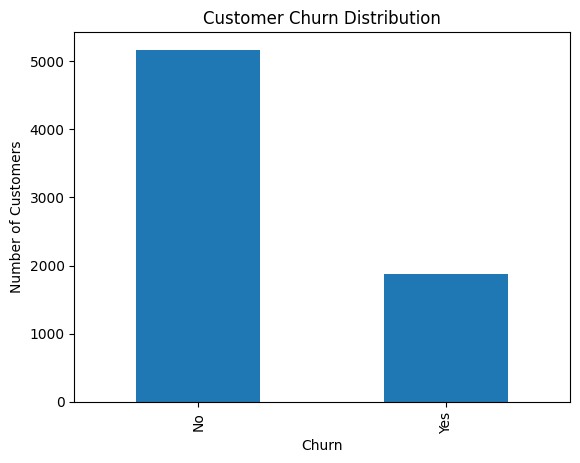

In [28]:
df["Churn"].value_counts().plot(kind="bar")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

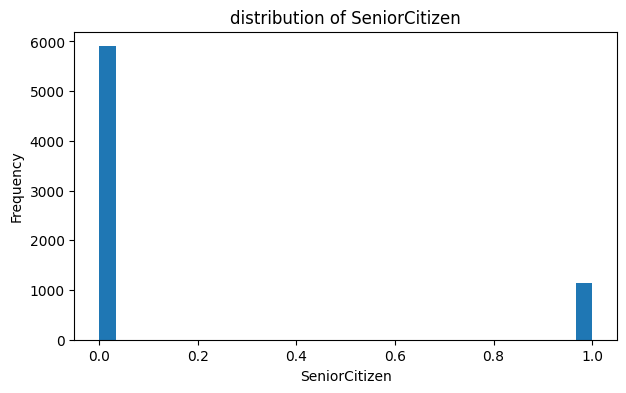

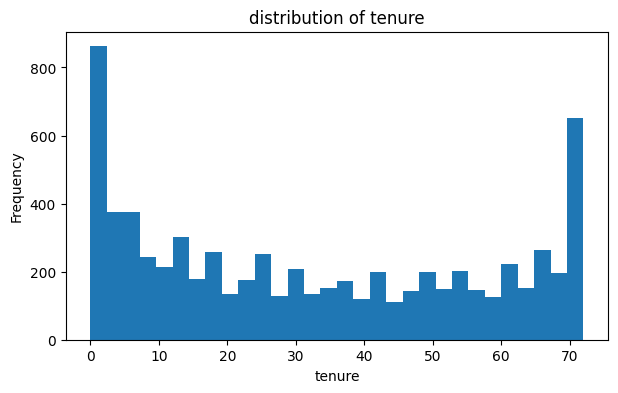

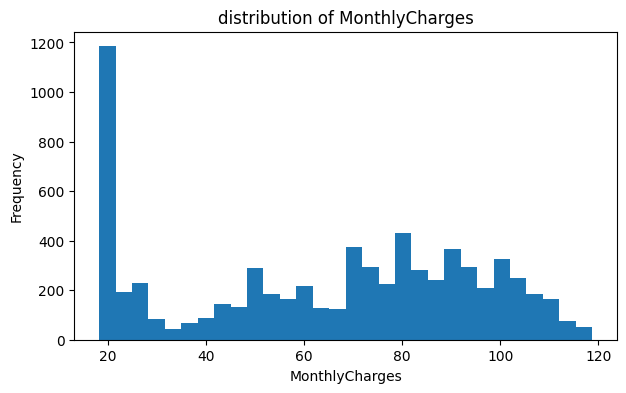

In [29]:
for col in num_cols:
    plt.figure(figsize=(7,4))
    df[col].plot(kind="hist",bins=30)
    plt.title(f"distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

In [30]:
#target VS Numerical
#do customers who churn have diff tenure distri than non churners

In [31]:
df.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


Text(0, 0.5, 'Tenure (months)')

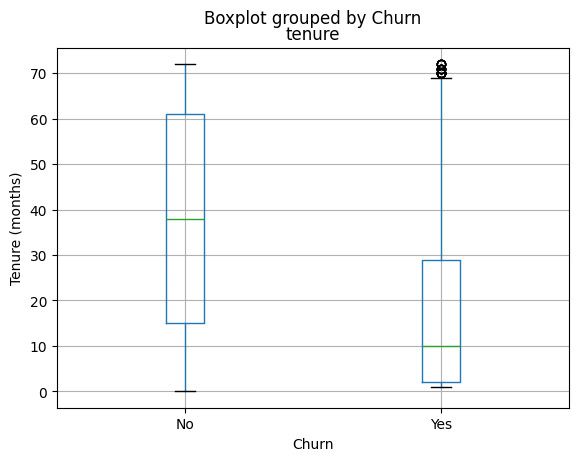

In [32]:
df.boxplot(column="tenure",by="Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (months)")

Text(0, 0.5, 'MonthlyCharges')

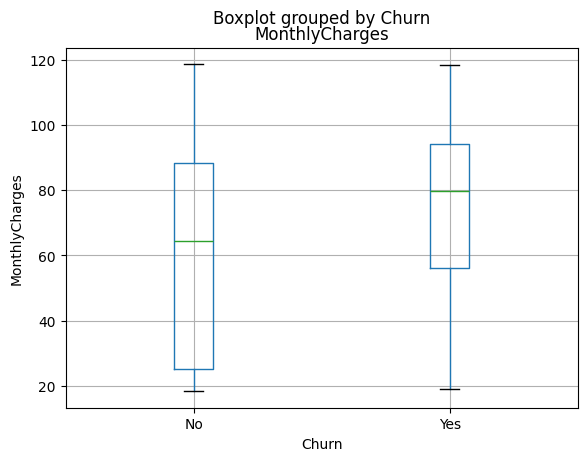

In [33]:
df.boxplot(column="MonthlyCharges",by="Churn")
plt.xlabel("Churn")
plt.ylabel("MonthlyCharges")

In [34]:
continuous_cols=["tenure","MonthlyCharges"]
df[continuous_cols].skew()

tenure            0.239540
MonthlyCharges   -0.220524
dtype: float64

In [35]:
df.groupby("Churn")[continuous_cols].mean()

,tenure,MonthlyCharges
Churn,,
No,37.569965,61.265124
Yes,17.979133,74.441332


In [36]:
df.groupby("Churn")[continuous_cols].median()

,tenure,MonthlyCharges
Churn,,
No,38.0,64.425
Yes,10.0,79.650


In [37]:
cat_cols=df.select_dtypes(include="object").columns.tolist()
cat_cols

['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'TotalCharges',
 'Churn']

In [38]:
cat_cols=[col for col in cat_cols if col not in ["Churn","customerID"]]
cat_cols        

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'TotalCharges']

In [39]:
for col in cat_cols:
    print(f"{col}")
    print(df[col].value_counts(dropna=False))

gender
gender
Male      3555
Female    3488
Name: count, dtype: int64
Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64
Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64
OnlineBackup
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64
DeviceProtection
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64
TechSupport
TechSupport
No                     34

In [40]:
pd.crosstab(df["Contract"],df["Churn"],normalize="index")*100 #within each contract how many churned

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [41]:
for col in cat_cols:
    print(pd.crosstab(df[col],df["Churn"],normalize="index")*100)
    print("_______________________________________________________")

Churn          No        Yes
gender                      
Female  73.079128  26.920872
Male    73.839662  26.160338
_______________________________________________________
Churn           No        Yes
Partner                      
No       67.042021  32.957979
Yes      80.335097  19.664903
_______________________________________________________
Churn              No        Yes
Dependents                      
No          68.720860  31.279140
Yes         84.549763  15.450237
_______________________________________________________
Churn                No        Yes
PhoneService                      
No            75.073314  24.926686
Yes           73.290363  26.709637
_______________________________________________________
Churn                    No        Yes
MultipleLines                         
No                74.955752  25.044248
No phone service  75.073314  24.926686
Yes               71.390104  28.609896
_______________________________________________________
Churn            

In [42]:
df.groupby("Contract")["Churn"]

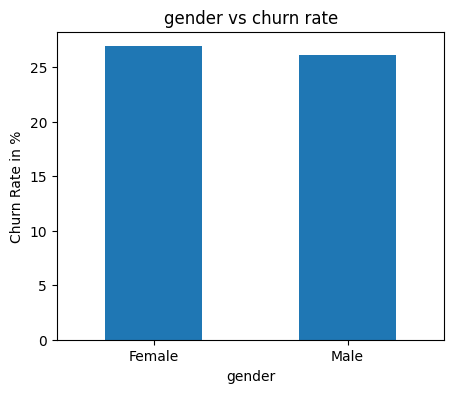

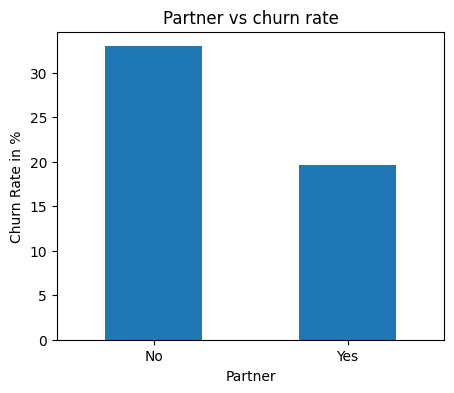

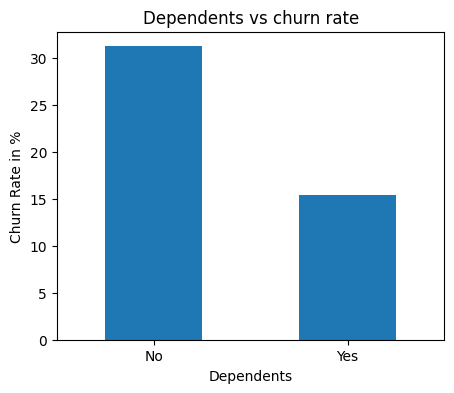

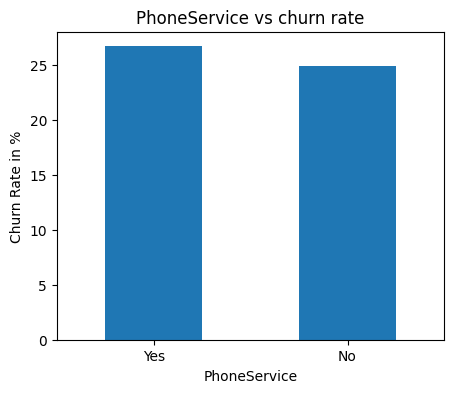

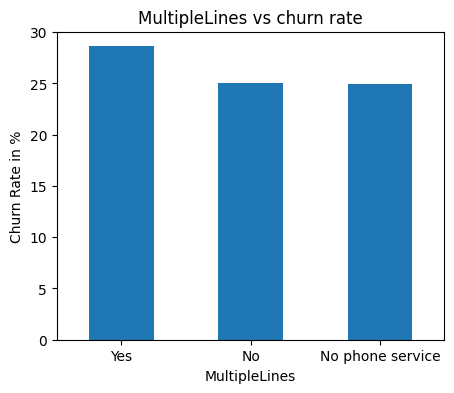

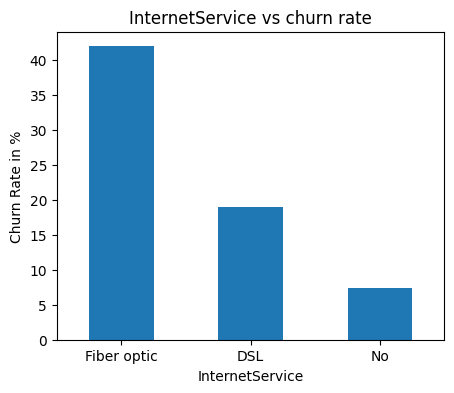

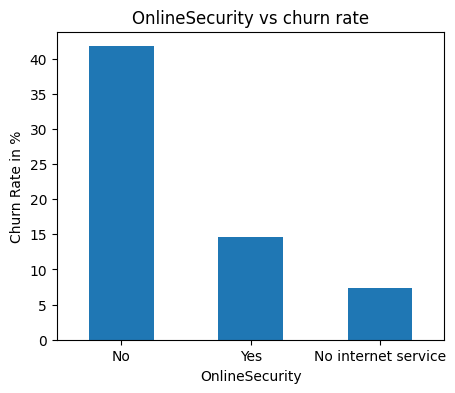

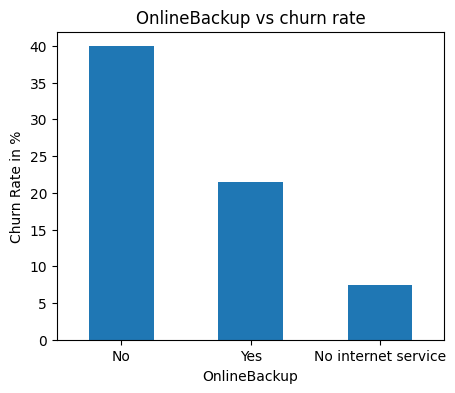

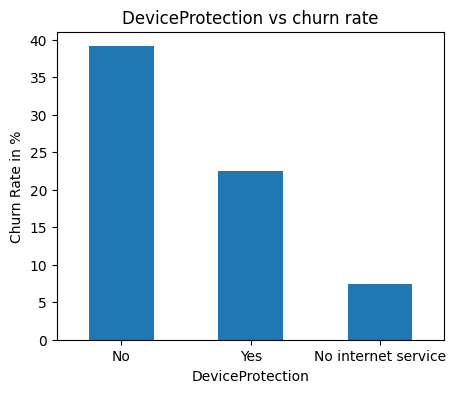

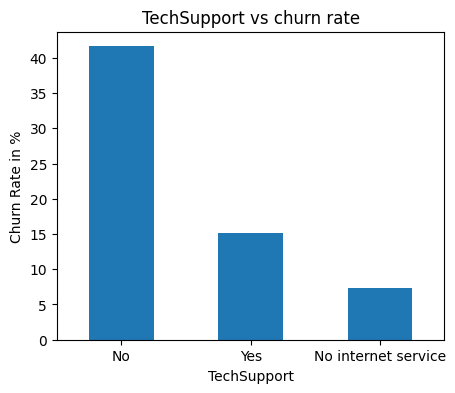

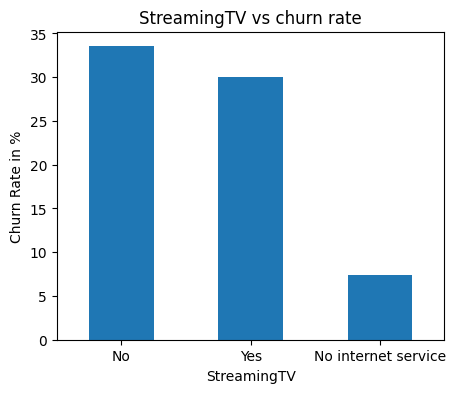

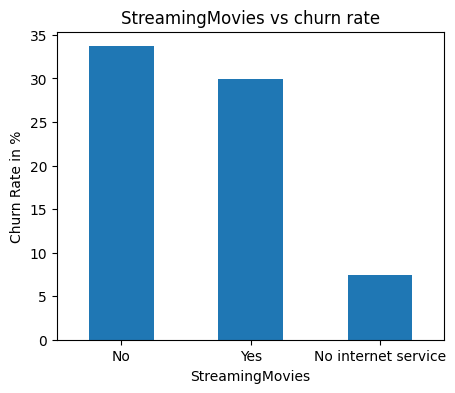

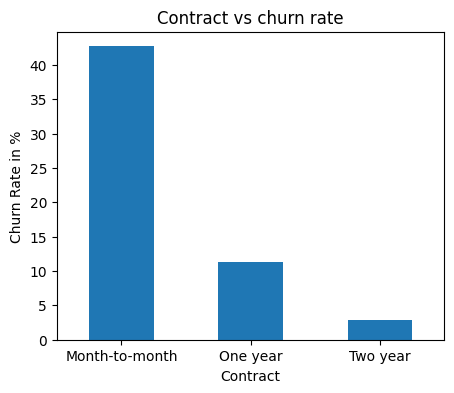

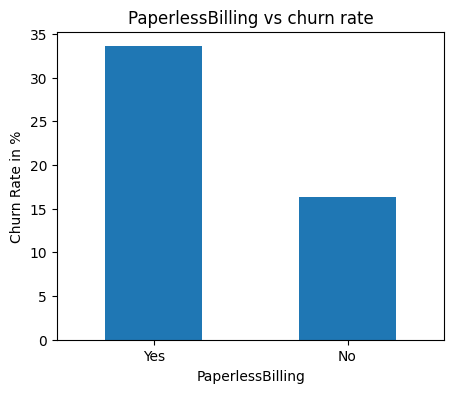

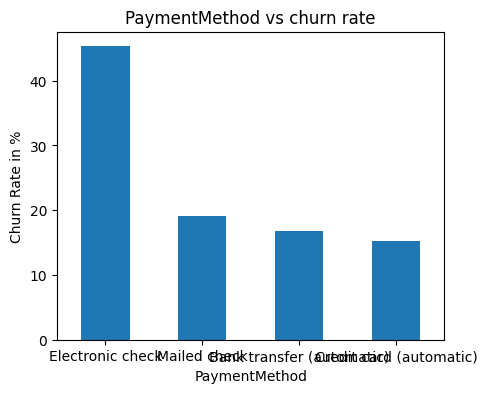

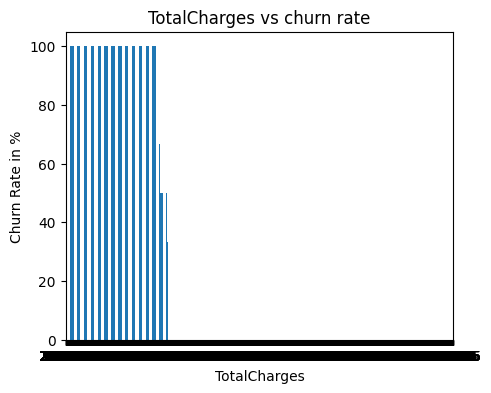

In [43]:
for col in cat_cols:
    churn_rate=(df.groupby(col)["Churn"].apply(lambda x:(x=="Yes").mean()*100)).sort_values(ascending=False)
    plt.figure(figsize=(5,4))
    churn_rate.plot(kind="bar")
    plt.title(f"{col} vs churn rate")
    plt.xlabel(col)
    plt.ylabel("Churn Rate in %")
    plt.xticks(rotation=0,ha="center")             #also see sample size

In [44]:
pd.crosstab([df["Contract"],df["InternetService"]],df["Churn"],normalize="index")*100

Churn                                  No        Yes
Contract       InternetService                      
Month-to-month DSL              67.784137  32.215863
               Fiber optic      45.394737  54.605263
               No               81.106870  18.893130
One year       DSL              90.701754   9.298246
               Fiber optic      80.705009  19.294991
               No               97.527473   2.472527
Two year       DSL              98.089172   1.910828
               Fiber optic      92.773893   7.226107
               No               99.216301   0.783699

In [45]:
df["tenure_group"]=pd.cut(df["tenure"],bins=[-1,12,24,48,72],labels=["0-12","13-24","25-48","49-72"])

In [46]:
pd.crosstab([df["Contract"],df["tenure_group"]],df["Churn"],normalize="index")*100

Churn                                No        Yes
Contract       tenure_group                       
Month-to-month 0-12           48.645938  51.354062
               13-24          62.279512  37.720488
               25-48          67.082294  32.917706
               49-72          73.976608  26.023392
One year       0-12           89.516129  10.483871
               13-24          91.878173   8.121827
               25-48          89.382239  10.617761
               49-72          87.066246  12.933754
Two year       0-12          100.000000   0.000000
               13-24         100.000000   0.000000
               25-48          97.810219   2.189781
               49-72          96.674584   3.325416

In [47]:
tenure_churn=(df.groupby("tenure_group",observed=True)["Churn"].apply(lambda x:(x=="Yes").mean()*100) )
tenure_churn

tenure_group
0-12     47.438243
13-24    28.710938
25-48    20.388959
49-72     9.513176
Name: Churn, dtype: float64

(array([0, 1, 2, 3]),
 [Text(0, 0, '0-12'),
  Text(1, 0, '13-24'),
  Text(2, 0, '25-48'),
  Text(3, 0, '49-72')])

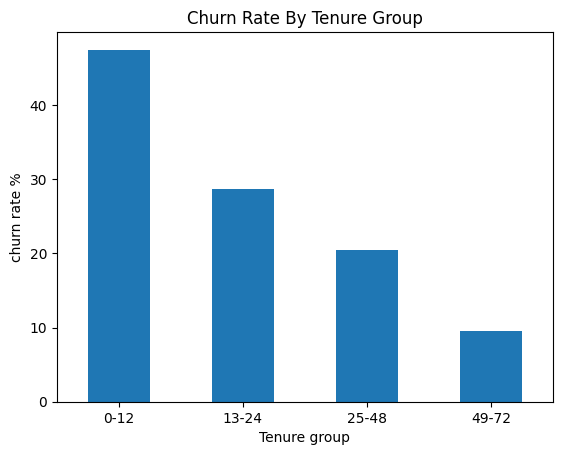

In [48]:
tenure_churn.plot(kind="bar")
plt.title("Churn Rate By Tenure Group")
plt.xlabel("Tenure group")
plt.ylabel("churn rate %")
plt.xticks(rotation=0)

Text(0, 0.5, 'Montly Charges')

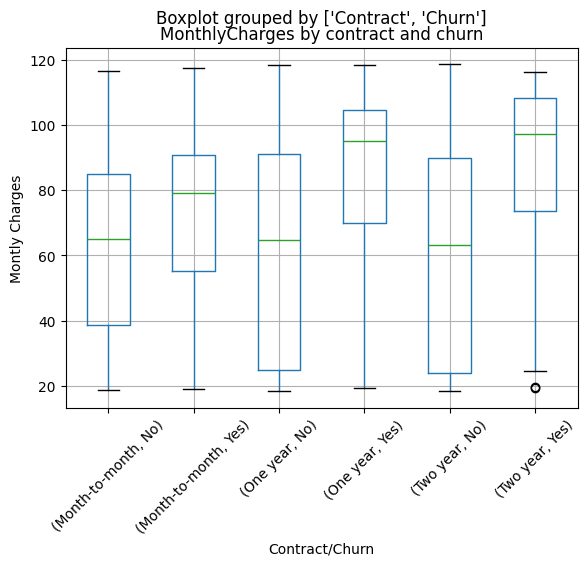

In [49]:
df.boxplot(column="MonthlyCharges",by=["Contract","Churn"],rot=45)
plt.title("MonthlyCharges by contract and churn")
plt.xlabel("Contract/Churn")
plt.ylabel("Montly Charges")

In [50]:
#correlation analysis
df[num_cols].corr()

,SeniorCitizen,tenure,MonthlyCharges
SeniorCitizen,1.000000,0.016567,0.220173
tenure,0.016567,1.000000,0.247900
MonthlyCharges,0.220173,0.247900,1.000000


Text(0.5, 1.0, 'Nuumerical feature correlation')

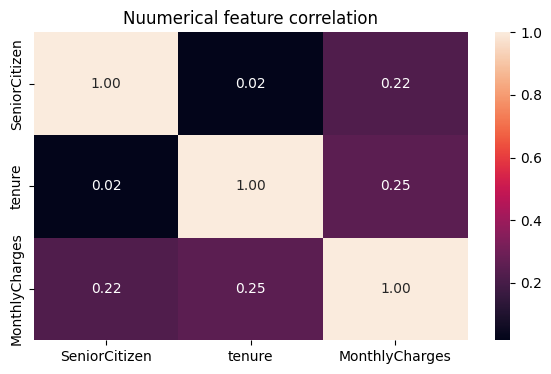

In [51]:
import seaborn as sns
plt.figure(figsize=(7,4))
sns.heatmap(df[num_cols].corr(),annot=True,fmt=".2f")
plt.title("Nuumerical feature correlation")

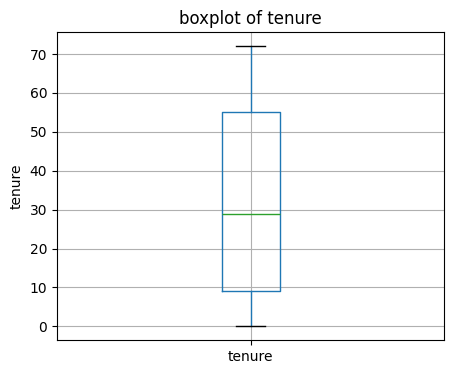

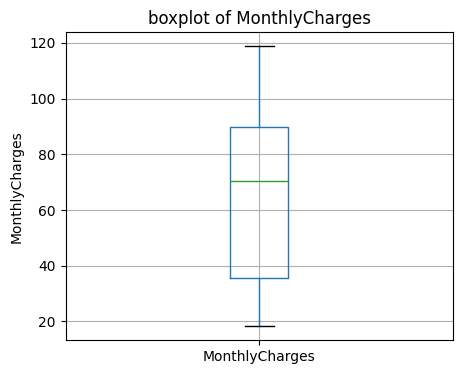

In [52]:
for col in ["tenure","MonthlyCharges"]:
    plt.figure(figsize=(5,4))
    df.boxplot(column=col)
    plt.title(f"boxplot of {col}")
    plt.ylabel(col)

In [53]:
df.drop(columns="tenure_group",inplace=True)

In [58]:
#leakage investigation(churn,Totalcharges)

In [59]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [60]:
x=df.drop(columns=["Churn","customerID"])
y=df["Churn"]

In [61]:
pd.crosstab([
    pd.cut(df["tenure"],[-1,12,24,48,72]),
    pd.qcut(df["MonthlyCharges"],3,duplicates="drop")],df["Churn"],normalize="index")*100

Churn                           No        Yes
tenure   MonthlyCharges                      
(-1, 12] (18.249, 50.4]  69.020021  30.979979
         (50.4, 83.9]    45.930233  54.069767
         (83.9, 118.75]  26.259947  73.740053
(12, 24] (18.249, 50.4]  89.473684  10.526316
         (50.4, 83.9]    71.544715  28.455285
         (83.9, 118.75]  48.639456  51.360544
(24, 48] (18.249, 50.4]  94.512195   5.487805
         (50.4, 83.9]    82.149712  17.850288
         (83.9, 118.75]  64.716007  35.283993
(48, 72] (18.249, 50.4]  97.449909   2.550091
         (50.4, 83.9]    94.453782   5.546218
         (83.9, 118.75]  84.840183  15.159817

# insights